# **WSINDy for ODEs: Examples**

- Based on the [JCP paper by **D. A. Messenger**, **D. M. Bortz** (2021)](https://www.sciencedirect.com/science/article/pii/S0021999121004204).
- See the authors' original [MatLab code repository](https://github.com/MathBioCU/WSINDy_PDE).

Seth Minor, 2026

---

This notebook illustrates the Weak SINDy algorithm being applied to various ODE systems:
- the logistic differential equation ($1$-dimensional)
- the Lotka-Volterra equations ($2$-dimensional)
- the Lorenz '63 equations ($3$-dimensional)

In [1]:
import sys
from collections import Counter
sys.path.append('../src')

import torch
import numpy as np
torch.set_default_dtype(torch.float64)

from scipy.integrate import solve_ivp
from IPython.display import display,Math

from wsindy import *

In [2]:
# Plot settings
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
#plt.rcParams['figure.dpi'] = 300

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

Constant settings

In [3]:
# Derivatives to include
alpha = [[1], # lhs = (d/dt)^1
         [0]] # (d/dt)^0

# SciPy ODE solver settings
solver_params = {'rtol':1e-12, 'atol':1e-12, 'method':'DOP853'}

Helpers for easy WSINDy fit with default settings

In [4]:
# Single ODE
def fit_wsindy_ode(Ui, V, names, t, beta, m=None, s=None, Lambda=None, rescale=True, verbosity=False):
  alpha = [[1], [0]] # lhs operator = d/dt
  model = WSINDy(Ui, alpha, beta, t, V=V, names=names, m=m, s=s,
                 verbosity=verbosity, rescale=rescale, eqn_type='ode')
  [G,powers,derivs,rhs_names] = model.create_default_library()
  model.build_lhs(names[0] + model.derivative_names[0])
  model.set_library(G, powers, derivs, rhs_names)
  display(Math(r'\Theta_{' + names[0] + r'}=' + r'\{' + r', \, '.join(model.rhs_names) + r'\}'))
  _ = model.MSTLS(Lambda=Lambda)
  model.print_report()
  ode = symbolic_eqn(model.lhs_name, model.rhs_names, model.coeffs)
  display(Math(ode))
  return model

# System of ODEs
def fit_wsindy_odes(states, t, names, beta, m=None, s=None, Lambda=None, rescale=True, verbosity=False):
  models = []

  for i,Ui in enumerate(states):
    aux_inds = [j for j in range(len(states)) if j != i]
    V = [states[j] for j in aux_inds]
    local_names = [names[i]] + [names[j] for j in aux_inds]

    model = fit_wsindy_ode(Ui, V, local_names, t, beta, m, s, Lambda, rescale, verbosity)
    models.append(model)
  return models

#### **LOGISTIC EQUATION**
$$\begin{align*}
  \dot u = r u\left(1 - \frac{u}{\kappa}\right),
  \quad \text{with} \quad
  \begin{cases}
    r = 1.5,
    \\
    K=2.
  \end{cases}
\end{align*}$$

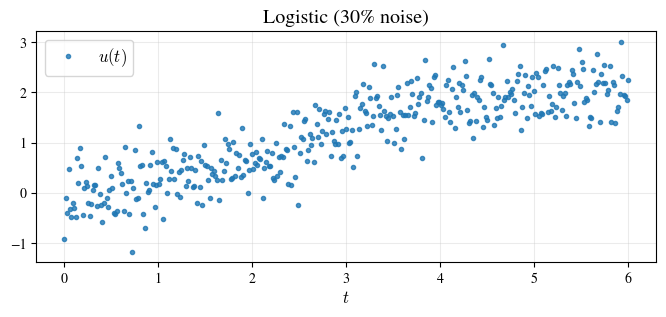

In [8]:
# Generate data
T, Nt = 6, 401
t = torch.linspace(0,T,Nt)

r, kappa = 1.5, 2.0
def logistic(t, u):
  return r*u*(1 - u/kappa)
  
soln = solve_ivp(logistic, (t[0], t[-1]), [0.05], t_eval=t, rtol=1e-12, atol=1e-12, method='DOP853')
logistic_clean = convert_to_torch(soln)

# Add noise and plotchange
#noise = 0.1
noise = 0.3
names = ['u']
title = f'Logistic ({noise*100:.0f}% noise)'
torch.manual_seed(0)

[U] = add_noise_to_states(logistic_clean, noise)
plot_states_ode(t, [U], names, title, ls='.', alpha=0.8)

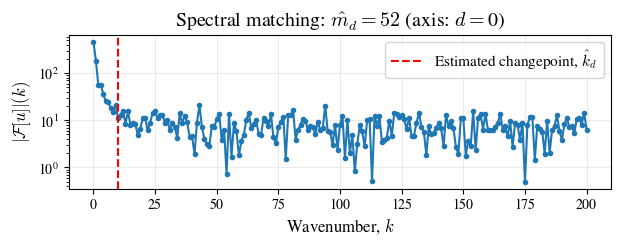

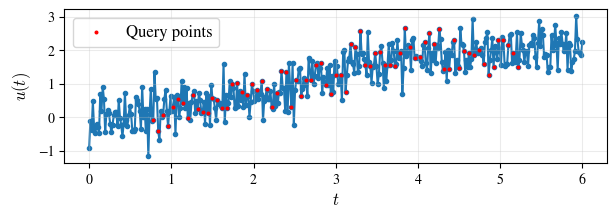

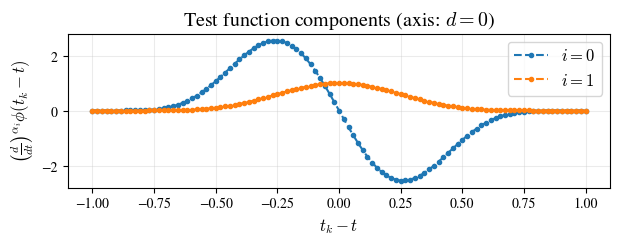

100%|██████████| 1/1 [00:00<00:00, 920.21it/s]


<IPython.core.display.Math object>


HYPER-PARAMETERS
m = [52]
p = [8]
s = [4]
yt = 1.282
yu = 0.708
Aux. scales = []

LIBRARY
Number of query points = 75
Number of candidate terms = 3
Condition number = 2.94e+01

RESULTS
ODE: u_{t} = + 1.60(u) - 0.76(u^2)
Nonzero terms = 2
Relative L2 error = 0.500
R^2 = 0.323
Lambda = 7.56e-02
Loss = 0.745


<IPython.core.display.Math object>

In [9]:
# Run WSINDy
V = [] # aux variables
beta = [[0], # u^0
        [1], # u^1
        [2]] # u^2

model = fit_wsindy_ode(U, V, names, t, beta, verbosity=True)

100%|██████████| 53/53 [00:11<00:00,  4.62it/s]


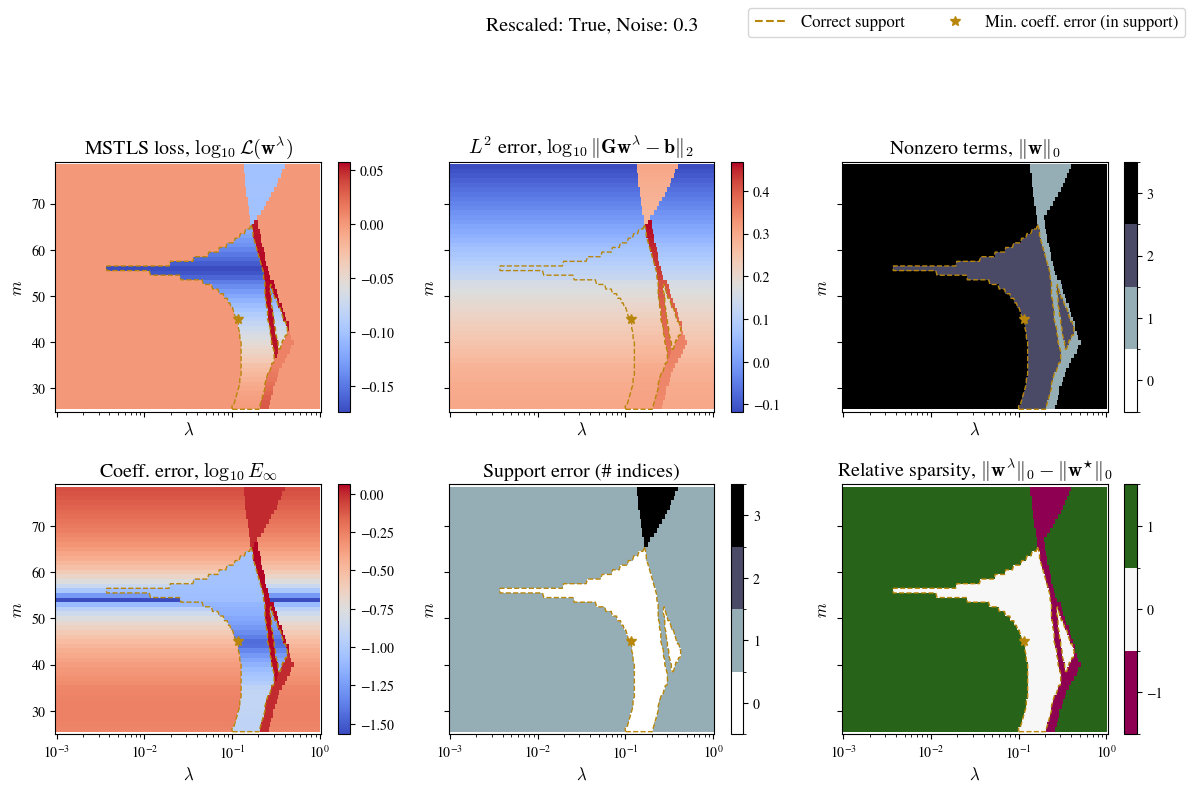

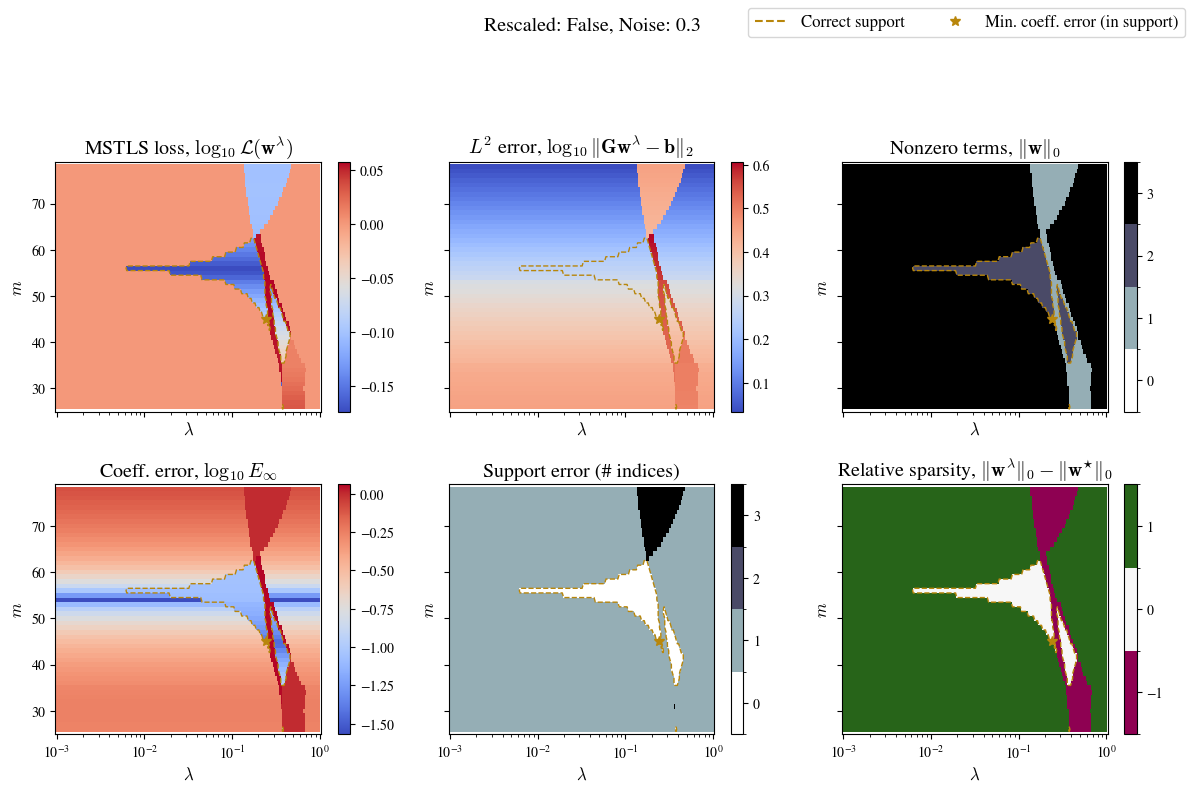

True model: u_{t} = 1.5(u) + -0.75(u^2)
1425/21200 fits: u_{t} = + 0.37(1) + 0.66(u) - 0.37(u^2)
708/21200 fits: u_{t} = + 0.36(1) + 0.67(u) - 0.37(u^2)
501/21200 fits: u_{t} = + 1.63(u) - 0.77(u^2)
385/21200 fits: u_{t} = - 0.23(1) + 2.16(u) - 0.99(u^2)


In [10]:
# Hyperparameter sweep
true_coeffs = {'(u)': 1.5, '(u^2)': -0.75}
true_model = model.lhs_name + ' = ' + ' + '.join(str(true_coeffs[term])+term for term in true_coeffs)

results = model.hyperparameter_sweep(lhs_name=model.lhs_name, true_coeffs=true_coeffs, noise=noise)

# Print most common models
print(f'True model: {true_model}')
for model_str,count in Counter(results['model']).most_common(4):
  print(f'{count:3d}/{len(results["model"])} fits: {model_str}')

#### **LOTKA-VOLTERRA**
$$\begin{align*}
  \begin{cases}
    \dot{x} = +ax - bxy,\\
    \dot{y} = -cy + dxy,
  \end{cases}
  \quad \text{with} \quad
  \begin{cases}
    a = 1.5,
    \\
    b = 1,
    \\
    c = 3,
    \\
    d = 1.
  \end{cases}
\end{align*}$$

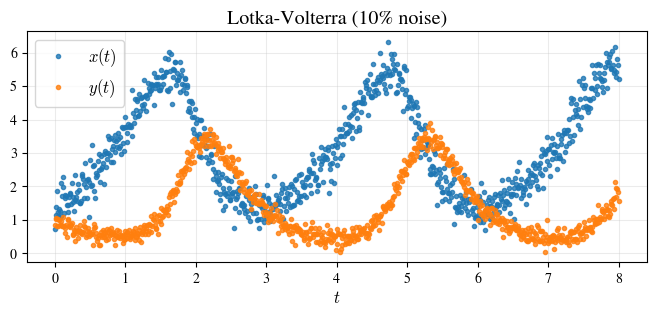

In [7]:
# Generate data
t = torch.linspace(0, 8, 801)
#t = torch.linspace(0, 8, 1001)

a, b, c, d = 1.5, 1.0, 3.0, 1.0
def lotka_volterra(t, z):
  x,y = z
  return [a*x - b*x*y, -c*y + d*x*y]
sol = solve_ivp(lotka_volterra, (t[0],t[-1]), [1.5,1.0], t_eval=t, rtol=1e-12, atol=1e-12, method='DOP853')
lv_clean = convert_to_torch(sol)

# Add noise and plot
noise = 0.10
names = ['x', 'y']
title = f'Lotka-Volterra ({noise*100:.0f}% noise)'
torch.manual_seed(0)

[x,y] = add_noise_to_states(lv_clean, noise)
plot_states_ode(t, [x,y], names, title, ls='.', alpha=0.8)

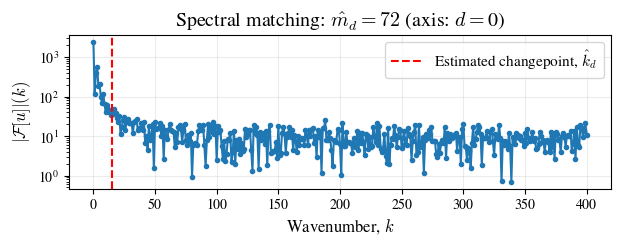

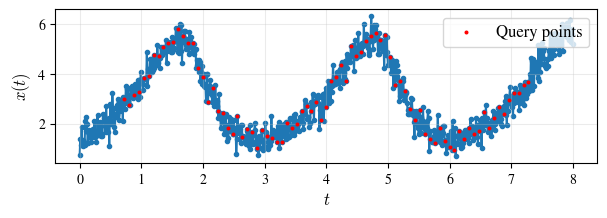

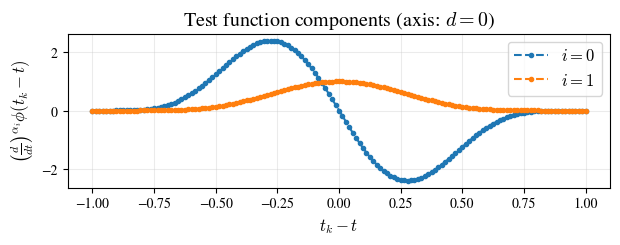

100%|██████████| 1/1 [00:00<00:00, 833.53it/s]


<IPython.core.display.Math object>


HYPER-PARAMETERS
m = [72]
p = [7]
s = [8]
yt = 1.389
yu = 0.473
Aux. scales = [0.607]

LIBRARY
Number of query points = 83
Number of candidate terms = 6
Condition number = 3.45e+02

RESULTS
ODE: x_{t} = + 1.44(x) - 0.97(x y)
Nonzero terms = 2
Relative L2 error = 0.048
R^2 = 0.998
Lambda = 1.32e-01
Loss = 0.355


<IPython.core.display.Math object>

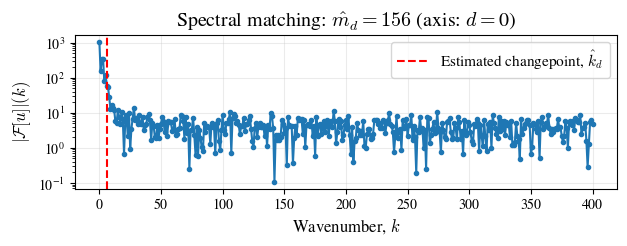

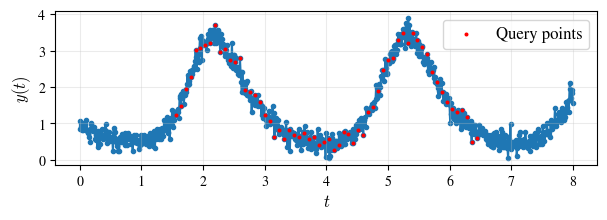

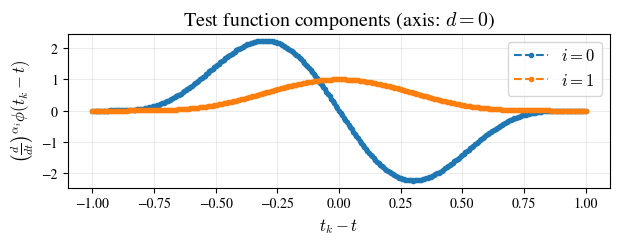

100%|██████████| 1/1 [00:00<00:00, 826.30it/s]


<IPython.core.display.Math object>


HYPER-PARAMETERS
m = [156]
p = [6]
s = [8]
yt = 0.641
yu = 0.607
Aux. scales = [0.473]

LIBRARY
Number of query points = 62
Number of candidate terms = 6
Condition number = 2.44e+03

RESULTS
ODE: y_{t} = - 3.05(y) + 1.02(y x)
Nonzero terms = 2
Relative L2 error = 0.012
R^2 = 1.000
Lambda = 1.32e-01
Loss = 0.341


<IPython.core.display.Math object>

In [ ]:
# Run WSINDy
states = [x,y]
beta = [[0,0],
        [1,0],
        [0,1],
        [2,0],
        [1,1],
        [0,2]]

models = fit_wsindy_odes(states, t, names, beta, verbosity=True)

In [ ]:
# HYPERPARAMETER SWEEP
alpha = [[1],
         [0]]
beta = [[0,0],
        [1,0],
        [0,1],
        [2,0],
        [1,1],
        [0,2]]

#model = WSINDy(x, alpha, beta, t, V=[y], names=['x','y'], m=[20], p=[10], s=[1], verbosity=False, eqn_type='ode')
model = WSINDy(x, alpha, beta, t, V=[y], names=['x','y'], s=[1], verbosity=False, eqn_type='ode')
true_coeffs = {'(x)': 1.5, '(x y)': -1.0}
results = model.hyperparameter_sweep(lhs_name='x_{t}', true_coeffs=true_coeffs)

#### **LORENZ '63**
$$\begin{align*}
  \begin{cases}
    \dot{x} = \sigma(y-x),\\
    \dot{y} = x(\rho-z)-y,\\
    \dot{z} = xy-\beta z,
  \end{cases}
  \quad \text{with} \quad
  \begin{cases}
    \sigma = 10,
    \\
    \rho = 28,
    \\
    \beta = 8/3.
  \end{cases}
\end{align*}$$

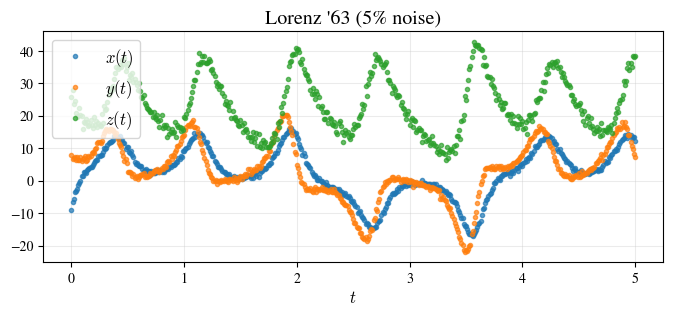

In [9]:
# Generate data
t = torch.linspace(0, 5, 501)

sigma, rho, beta = 10.0, 28.0, 8/3
def lorenz_rhs(t, z):
  x,y,z0 = z
  return [sigma*(y-x), x*(rho-z0)-y, x*y-beta*z0]
sol = solve_ivp(lorenz_rhs, (t[0], t[-1]), [-8.0, 8.0, 27.0], t_eval=t, rtol=1e-12, atol=1e-12, method='DOP853')
lorenz_clean = convert_to_torch(sol)

# Add noise and plot
noise = 0.05
names = ['x','y','z']
title = f"Lorenz '63 ({noise*100:.0f}% noise)"
torch.manual_seed(0)

[x,y,z] = add_noise_to_states(lorenz_clean, noise)
plot_states_ode(t, [x,y,z], names, title, ls='.', alpha=0.7)

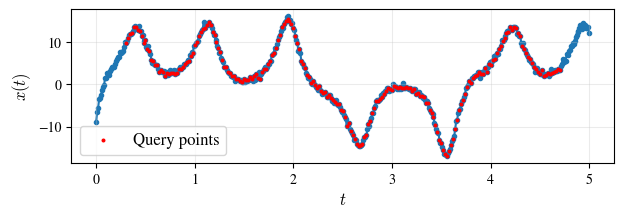

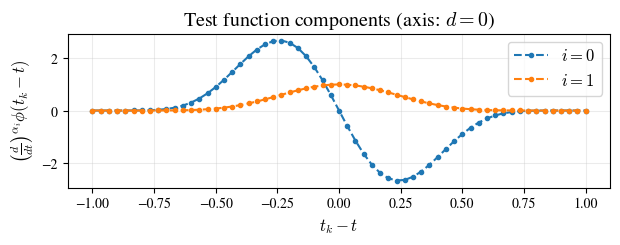

100%|██████████| 1/1 [00:00<00:00, 471.01it/s]


<IPython.core.display.Math object>


HYPER-PARAMETERS
m = [30]
p = [9]
s = [2]
yt = 3.333
yu = 0.287
Aux. scales = [0.257, 0.181]

LIBRARY
Number of query points = 221
Number of candidate terms = 10
Condition number = 8.18e+02

RESULTS
ODE: x_{t} = - 9.96(x) + 9.93(y)
Nonzero terms = 2
Relative L2 error = 0.038
R^2 = 0.999
Lambda = 2.15e-02
Loss = 0.219


<IPython.core.display.Math object>

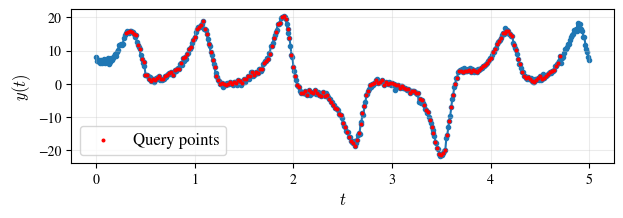

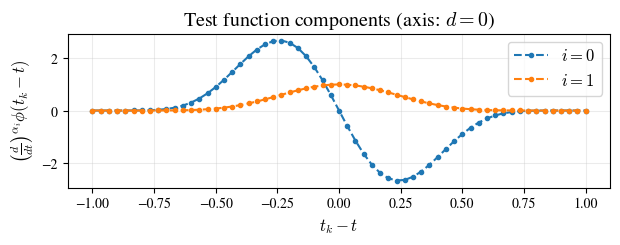

100%|██████████| 1/1 [00:00<00:00, 424.87it/s]


<IPython.core.display.Math object>


HYPER-PARAMETERS
m = [30]
p = [9]
s = [2]
yt = 3.333
yu = 0.257
Aux. scales = [0.287, 0.181]

LIBRARY
Number of query points = 221
Number of candidate terms = 10
Condition number = 8.18e+02

RESULTS
ODE: y_{t} = - 0.87(y) + 27.83(x) - 1.00(x z)
Nonzero terms = 3
Relative L2 error = 0.060
R^2 = 0.996
Lambda = 8.70e-02
Loss = 0.333


<IPython.core.display.Math object>

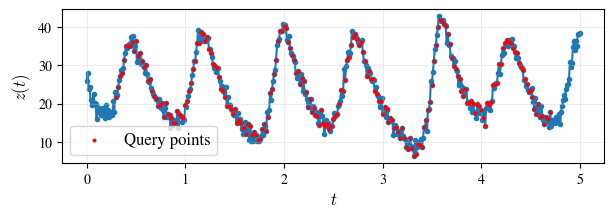

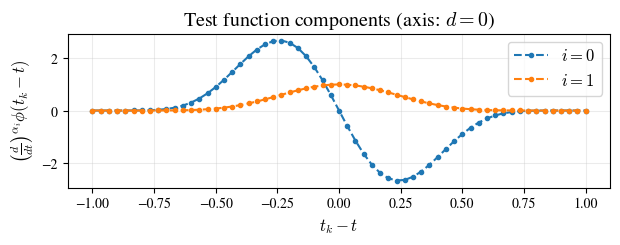

100%|██████████| 1/1 [00:00<00:00, 425.39it/s]


<IPython.core.display.Math object>


HYPER-PARAMETERS
m = [30]
p = [9]
s = [2]
yt = 3.333
yu = 0.181
Aux. scales = [0.287, 0.257]

LIBRARY
Number of query points = 221
Number of candidate terms = 10
Condition number = 8.18e+02

RESULTS
ODE: z_{t} = - 2.67(z) + 1.00(x y)
Nonzero terms = 2
Relative L2 error = 0.036
R^2 = 0.999
Lambda = 6.14e-02
Loss = 0.217


<IPython.core.display.Math object>

In [ ]:
# Run WSINDy
states = [x,y,z]
beta = [[0,0,0],
        [1,0,0],
        [0,1,0],
        [0,0,1],
        [2,0,0],
        [1,1,0],
        [1,0,1],
        [0,2,0],
        [0,1,1],
        [0,0,2]]
        
models = fit_wsindy_odes(states, t, names, beta, m=[30], s=[2], verbosity=True, rescale=True)

#### **HYPERPARAMETER SWEEPS**

100%|██████████| 40/40 [00:06<00:00,  6.20it/s]


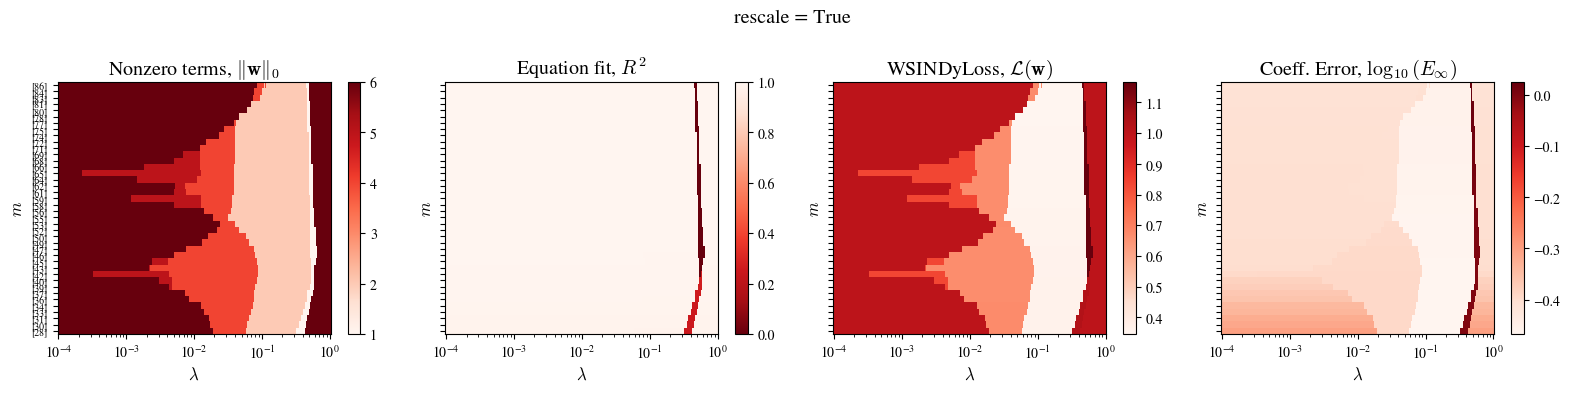

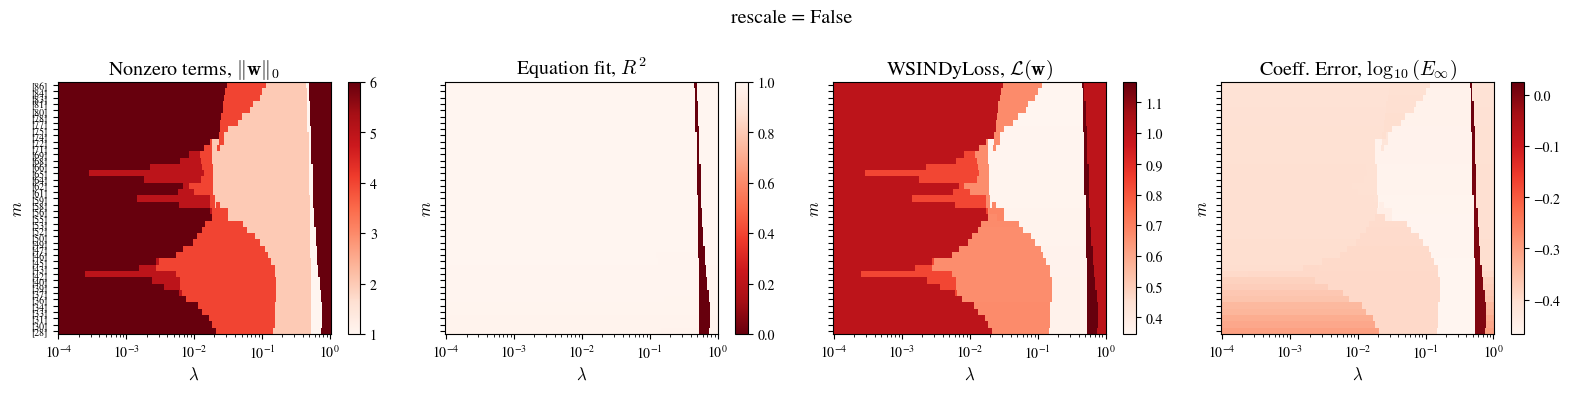

In [39]:
# Lotka-Volterra x-equation at 5% noise
T, Nt = 6, 401
t = torch.linspace(0, T, Nt)

torch.manual_seed(0)
[x,y] = add_noise_to_states(lv_clean, 0.05)

alpha = [[1],
         [0]]
beta = [[0,0],
        [1,0],
        [0,1],
        [2,0],
        [1,1],
        [0,2]]

#model = WSINDy(x, alpha, beta, t, V=[y], names=['x','y'], m=[20], p=[10], s=[1], verbosity=False, eqn_type='ode')
model = WSINDy(x, alpha, beta, t, V=[y], names=['x','y'], s=[1], verbosity=False, eqn_type='ode')
true_coeffs = {'(x)': 1.5, '(x y)': -1.0}
results = model.hyperparameter_sweep(lhs_name='x_{t}', true_coeffs=true_coeffs)

In [40]:
# Most common models across the sweep
from collections import Counter

for model_str,count in Counter(results['model']).most_common(4):
  print(f'{count:3d}/{len(results["model"])} fits: {model_str}')

1659/16000 fits: x_{t} = + 0.98(x) - 0.65(x y)
1201/16000 fits: x_{t} = + 0.99(x) - 0.66(x y)
718/16000 fits: x_{t} = + 0.98(x) - 0.66(x y)
550/16000 fits: x_{t} = + 0.32(1) + 0.89(x) - 0.18(y) - 0.60(x y)


100%|██████████| 40/40 [00:07<00:00,  5.13it/s]


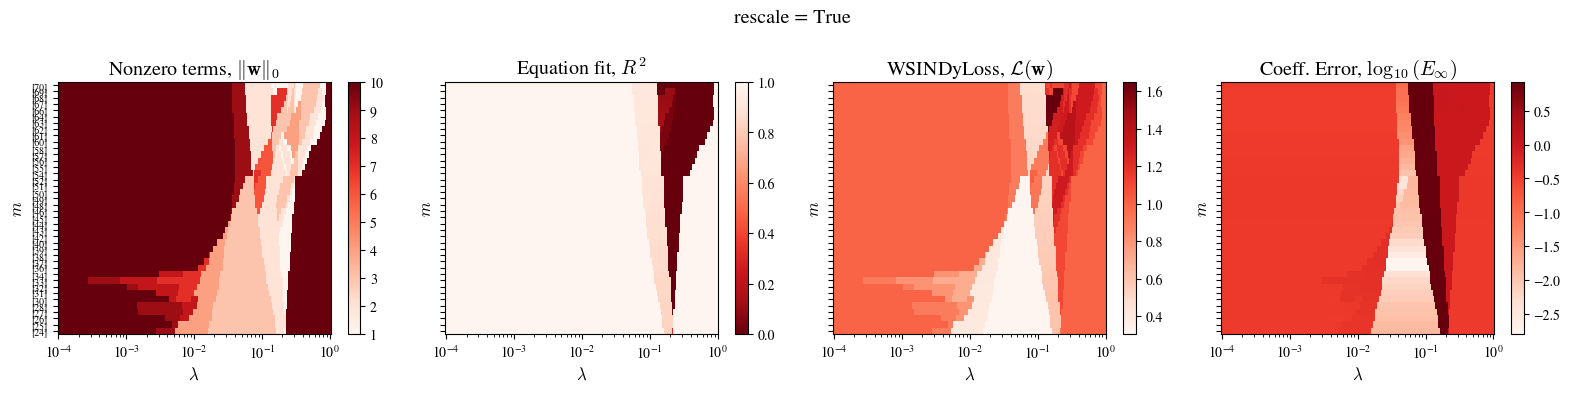

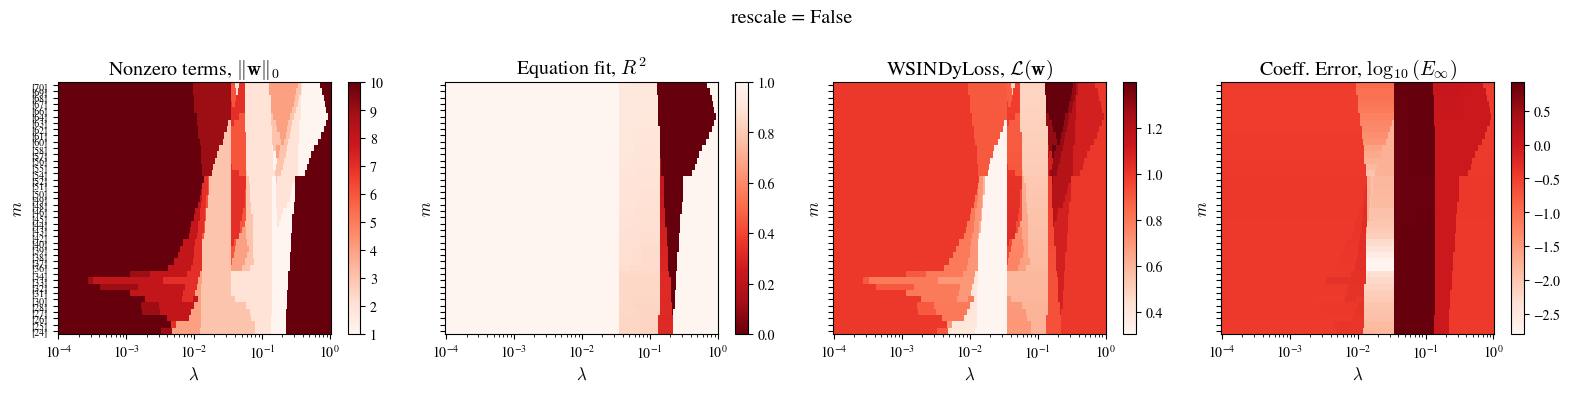

In [53]:
# Lorenz '63 x-equation at 5% noise
T, Nt = 5, 501
t = torch.tensor(np.linspace(0, T, Nt))

torch.manual_seed(0)
#[x,y,z] = add_noise_to_states(lorenz_clean, 0.05)
[x,y,z] = add_noise_to_states(lorenz_clean, 0.01)

alpha = [[1],
         [0]]
beta = [[0,0,0],
        [1,0,0],
        [0,1,0],
        [0,0,1],
        [2,0,0],
        [1,1,0],
        [1,0,1],
        [0,2,0],
        [0,1,1],
        [0,0,2]]

# model = WSINDy(x, alpha, beta, t, V=[y,z], names=['x','y','z'], s=[1], verbosity=False, eqn_type='ode')
# true_coeffs = {'(x)': -10.0, '(y)': 10.0}
# results = model.hyperparameter_sweep(lhs_name='x_{t}', true_coeffs=true_coeffs)
model = WSINDy(y, alpha, beta, t, V=[x,z], names=['y','x','z'], s=[1], verbosity=False, eqn_type='ode')
true_coeffs = {'(x)': 28.0, '(y)': -1.0, '(x z)': -1.0}
results = model.hyperparameter_sweep(lhs_name='y_{t}', true_coeffs=true_coeffs)

In [54]:
# Most common models across the sweep
from collections import Counter

for model_str,count in Counter(results['model']).most_common(4):
  print(f'{count:3d}/{len(results["model"])} fits: {model_str}')

380/16000 fits: y_{t} = - 0.99(y) + 28.03(x) - 1.00(x z)
289/16000 fits: y_{t} = + 2.73(1) - 1.37(y) + 28.53(x) - 0.39(z) - 0.06(y^2) + 0.17(y x) + 0.01(y z) - 0.12(x^2) - 1.02(x z) + 0.01(z^2)
287/16000 fits: y_{t} = + 2.61(1) - 1.37(y) + 28.53(x) - 0.38(z) - 0.06(y^2) + 0.16(y x) + 0.01(y z) - 0.12(x^2) - 1.02(x z) + 0.01(z^2)
286/16000 fits: y_{t} = + 2.50(1) - 1.37(y) + 28.52(x) - 0.36(z) - 0.06(y^2) + 0.16(y x) + 0.01(y z) - 0.11(x^2) - 1.02(x z) + 0.01(z^2)
